In [9]:
# Step 1 — install waymo package WITHOUT enforcing TF version
!pip install -q waymo-open-dataset-tf-2-12-0 --no-deps

# Step 2 — install the deps it actually needs separately
!pip install -q tensorflow numpy pandas matplotlib seaborn tqdm protobuf

# Step 3 — verify
import tensorflow as tf
print(f"TF version: {tf.__version__}")

from waymo_open_dataset.protos import scenario_pb2
print("✅ waymo_open_dataset imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 19.2 MB/s eta 0:00:00
TF version: 2.19.0
✅ waymo_open_dataset imported successfully


In [2]:
import google.cloud.storage as storage
from google.colab import auth

PROJECT_ID = 'womd-imitation'
WOMD_BUCKET = 'waymo_open_dataset_motion_v_1_3_1'

auth.authenticate_user()
_gcs = storage.Client(project=PROJECT_ID)

# Check what's actually in the validation folder
womd_bucket = _gcs.bucket(WOMD_BUCKET)

# List first 10 objects with no filter
blobs = list(womd_bucket.list_blobs(prefix='uncompressed/scenario/validation/', max_results=10))
print(f"Total blobs found: {len(blobs)}")
for b in blobs:
    print(f"  name: {b.name}")
    print(f"  size: {b.size}")

Total blobs found: 10
  name: uncompressed/scenario/validation/validation.tfrecord-00000-of-00150
  size: 262636608
  name: uncompressed/scenario/validation/validation.tfrecord-00001-of-00150
  size: 286425611
  name: uncompressed/scenario/validation/validation.tfrecord-00002-of-00150
  size: 271464873
  name: uncompressed/scenario/validation/validation.tfrecord-00003-of-00150
  size: 277970112
  name: uncompressed/scenario/validation/validation.tfrecord-00004-of-00150
  size: 260872317
  name: uncompressed/scenario/validation/validation.tfrecord-00005-of-00150
  size: 292975578
  name: uncompressed/scenario/validation/validation.tfrecord-00006-of-00150
  size: 291532778
  name: uncompressed/scenario/validation/validation.tfrecord-00007-of-00150
  size: 246887249
  name: uncompressed/scenario/validation/validation.tfrecord-00008-of-00150
  size: 291303216
  name: uncompressed/scenario/validation/validation.tfrecord-00009-of-00150
  size: 291553780


In [ ]:
# Fixed config cell — replace the previous one entirely
PROJECT_ID  = 'womd-imitation'
GCS_BUCKET  = 'womd-imitation-data'
WOMD_BUCKET = 'waymo_open_dataset_motion_v_1_3_1'

_gcs = storage.Client(project=PROJECT_ID)
womd_bucket = _gcs.bucket(WOMD_BUCKET)

# Fixed filter — match on prefix pattern instead of extension
val_blobs  = list(womd_bucket.list_blobs(prefix='uncompressed/scenario/validation/'))
val_shards = [b for b in val_blobs if 'tfrecord' in b.name]

train_blobs  = list(womd_bucket.list_blobs(prefix='uncompressed/scenario/training/'))
train_shards = [b for b in train_blobs if 'tfrecord' in b.name]

print(f'✅ Config set')
print(f'   Validation shards : {len(val_shards)}')
print(f'   Training shards   : {len(train_shards)}')
print(f'   First val shard   : gs://{WOMD_BUCKET}/{val_shards[0].name}')
print(f'   Shard size        : {val_shards[0].size / 1e6:.1f} MB')

✅ Config set
   Validation shards : 150
   Training shards   : 1000
   First val shard   : gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/validation/validation.tfrecord-00000-of-00150
   Shard size        : 262.6 MB


In [ ]:
from waymo_open_dataset.protos import scenario_pb2

SHARD_0 = f"gs://{WOMD_BUCKET}/{val_shards[0].name}"

dataset = tf.data.TFRecordDataset(SHARD_0, compression_type='')
for raw in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(raw.numpy())

print(f'Scenario ID     : {scenario.scenario_id}')
print(f'Timestamps      : {len(scenario.timestamps_seconds)} steps @ 10 Hz')
print(f'Tracks (agents) : {len(scenario.tracks)}')
print(f'To predict      : {len(scenario.tracks_to_predict)} agents')
print(f'Map features    : {len(scenario.map_features)}')
print()
print('✅ Scenario proto parsed — Phase 1 data access complete!')

Scenario ID     : b85e1bd6cc8e74c0
Timestamps      : 91 steps @ 10 Hz
Tracks (agents) : 14
To predict      : 2 agents
Map features    : 139

✅ Scenario proto parsed — Phase 1 data access complete!


#Phase 2 - Getting Started & Tail slicer (close-int + high-curv), feature extraction, saved to GCS

In [ ]:
import numpy as np

def slice_close_interaction(scenario, threshold_m=5.0) -> bool:
    """
    Returns True if any two tracks_to_predict agents come within
    threshold_m of each other at any shared valid timestep.
    """
    pred_tracks = [scenario.tracks[t.track_index]
                   for t in scenario.tracks_to_predict]
    if len(pred_tracks) < 2:
        return False

    for i in range(len(pred_tracks)):
        for j in range(i + 1, len(pred_tracks)):
            si = pred_tracks[i].states
            sj = pred_tracks[j].states
            for k in range(min(len(si), len(sj))):
                if si[k].valid and sj[k].valid:
                    dx = si[k].center_x - sj[k].center_x
                    dy = si[k].center_y - sj[k].center_y
                    if (dx*dx + dy*dy) ** 0.5 < threshold_m:
                        return True
    return False


def slice_high_curvature(scenario, radius_thresh_m=20.0) -> bool:
    """
    Returns True if any tracks_to_predict agent exhibits a turning
    radius below radius_thresh_m at any history timestep.
    Turning radius = speed^2 / lateral_acceleration (approx via heading rate).
    """
    HIST_STEPS = 11   # first 1.0 s = history window

    for req in scenario.tracks_to_predict:
        track = scenario.tracks[req.track_index]
        states = track.states[:HIST_STEPS]

        for k in range(1, len(states) - 1):
            if not (states[k-1].valid and states[k].valid and states[k+1].valid):
                continue

            speed = (states[k].velocity_x**2 + states[k].velocity_y**2) ** 0.5
            if speed < 1.0:   # ignore near-stationary agents
                continue

            # Heading rate (rad/s) at 10 Hz → dt = 0.1 s
            dh = states[k].heading - states[k-1].heading
            # Wrap to [-pi, pi]
            dh = (dh + np.pi) % (2 * np.pi) - np.pi
            heading_rate = abs(dh) / 0.1  # rad/s

            if heading_rate < 1e-3:
                continue

            radius = speed / heading_rate
            if radius < radius_thresh_m:
                return True
    return False


print("✅ Slicers defined")
print("   close_interaction : min inter-agent dist < 5 m")
print("   high_curvature    : turning radius < 20 m in history window")

✅ Slicers defined
   close_interaction : min inter-agent dist < 5 m
   high_curvature    : turning radius < 20 m in history window


In [ ]:
from waymo_open_dataset.protos import scenario_pb2

HIST_STEPS   = 11
FUTURE_STEPS = 80

AGENT_TYPE_INT = {
    scenario_pb2.Track.TYPE_VEHICLE    : 0,
    scenario_pb2.Track.TYPE_PEDESTRIAN : 1,
    scenario_pb2.Track.TYPE_CYCLIST    : 2,
    scenario_pb2.Track.TYPE_OTHER      : 3,
    scenario_pb2.Track.TYPE_UNSET      : 3,
}

def extract_features(scenario) -> list:
    records = []
    for req in scenario.tracks_to_predict:
        track  = scenario.tracks[req.track_index]
        states = track.states

        hist_xy    = np.zeros((HIST_STEPS, 2),   dtype=np.float32)
        hist_hv    = np.zeros((HIST_STEPS, 3),   dtype=np.float32)
        hist_valid = np.zeros((HIST_STEPS,),      dtype=bool)
        fut_xy     = np.zeros((FUTURE_STEPS, 2), dtype=np.float32)
        fut_valid  = np.zeros((FUTURE_STEPS,),    dtype=bool)

        for t in range(HIST_STEPS):
            if t < len(states) and states[t].valid:
                st = states[t]
                hist_xy[t]    = [st.center_x, st.center_y]
                hist_hv[t]    = [st.heading, st.velocity_x, st.velocity_y]
                hist_valid[t] = True

        for t in range(FUTURE_STEPS):
            idx = HIST_STEPS + t
            if idx < len(states) and states[idx].valid:
                st = states[idx]
                fut_xy[t]    = [st.center_x, st.center_y]
                fut_valid[t] = True

        # Normalize to last valid history position
        if hist_valid.any():
            origin = hist_xy[hist_valid][-1]  # last known position
        else:
            origin = np.zeros(2)

        records.append({
            'scenario_id'   : scenario.scenario_id,
            'track_index'   : req.track_index,
            'agent_type'    : AGENT_TYPE_INT.get(track.object_type, 3),
            'history_xy'    : hist_xy - origin,
            'history_hv'    : hist_hv,
            'history_valid' : hist_valid,
            'future_xy'     : fut_xy - origin,
            'future_valid'  : fut_valid,
            'origin'        : origin,
        })
    return records


print("✅ Feature extractor defined")

✅ Feature extractor defined


In [ ]:
import io
from tqdm import tqdm

N_SHARDS      = 5    # start small — each shard ~270 MB, takes ~2 min
MAX_SCENARIOS = 100  # per shard

def save_npz_to_gcs(features: list, labels: list, gcs_path: str):
    arrays = {
        'scenario_id'    : np.array([f['scenario_id']    for f in features]),
        'track_index'    : np.array([f['track_index']    for f in features]),
        'agent_type'     : np.array([f['agent_type']     for f in features]),
        'history_xy'     : np.stack([f['history_xy']     for f in features]),
        'history_hv'     : np.stack([f['history_hv']     for f in features]),
        'history_valid'  : np.stack([f['history_valid']  for f in features]),
        'future_xy'      : np.stack([f['future_xy']      for f in features]),
        'future_valid'   : np.stack([f['future_valid']   for f in features]),
        'origin'         : np.stack([f['origin']         for f in features]),
        'label_close_int': np.array([l['close_int']      for l in labels]),
        'label_high_curv': np.array([l['high_curv']      for l in labels]),
    }
    buf = io.BytesIO()
    np.savez_compressed(buf, **arrays)
    buf.seek(0)
    bucket = _gcs.bucket(GCS_BUCKET)
    blob   = bucket.blob(gcs_path)
    blob.upload_from_file(buf, content_type='application/octet-stream')


all_stats = {'total': 0, 'close_int': 0, 'high_curv': 0, 'both': 0}

for i, shard_blob in enumerate(tqdm(val_shards[:N_SHARDS], desc='Shards')):
    shard_path  = f"gs://{WOMD_BUCKET}/{shard_blob.name}"
    dataset     = tf.data.TFRecordDataset(shard_path, compression_type='')
    shard_feats = []
    shard_labels= []

    for j, raw in enumerate(dataset):
        if j >= MAX_SCENARIOS:
            break
        sc = scenario_pb2.Scenario()
        sc.ParseFromString(raw.numpy())

        is_close = slice_close_interaction(sc)
        is_curv  = slice_high_curvature(sc)

        feats = extract_features(sc)
        for f in feats:
            shard_feats.append(f)
            shard_labels.append({'close_int': is_close, 'high_curv': is_curv})

        all_stats['total']     += 1
        all_stats['close_int'] += int(is_close)
        all_stats['high_curv'] += int(is_curv)
        all_stats['both']      += int(is_close and is_curv)

    out_path = f"features/val/shard_{i:04d}.npz"
    save_npz_to_gcs(shard_feats, shard_labels, out_path)
    print(f"  Shard {i}: {len(shard_feats)} agent-samples → gs://{GCS_BUCKET}/{out_path}")

print(f"\n✅ Phase 2 complete")
print(f"   Scenarios processed : {all_stats['total']}")
print(f"   Close-interaction   : {all_stats['close_int']} ({100*all_stats['close_int']/all_stats['total']:.1f}%)")
print(f"   High-curvature      : {all_stats['high_curv']} ({100*all_stats['high_curv']/all_stats['total']:.1f}%)")
print(f"   Both (hardest tail) : {all_stats['both']} ({100*all_stats['both']/all_stats['total']:.1f}%)")

Shards:  20%|██        | 1/5 [00:03<00:14,  3.63s/it]

  Shard 0: 434 agent-samples → gs://womd-imitation-data/features/val/shard_0000.npz


Shards:  40%|████      | 2/5 [00:07<00:10,  3.66s/it]

  Shard 1: 412 agent-samples → gs://womd-imitation-data/features/val/shard_0001.npz


Shards:  60%|██████    | 3/5 [00:10<00:07,  3.59s/it]

  Shard 2: 407 agent-samples → gs://womd-imitation-data/features/val/shard_0002.npz


Shards:  80%|████████  | 4/5 [00:13<00:03,  3.37s/it]

  Shard 3: 439 agent-samples → gs://womd-imitation-data/features/val/shard_0003.npz


Shards: 100%|██████████| 5/5 [00:17<00:00,  3.47s/it]

  Shard 4: 459 agent-samples → gs://womd-imitation-data/features/val/shard_0004.npz

✅ Phase 2 complete
   Scenarios processed : 500
   Close-interaction   : 212 (42.4%)
   High-curvature      : 296 (59.2%)
   Both (hardest tail) : 139 (27.8%)


Total agent-samples : 2151
history_xy shape    : (2151, 11, 2)
future_xy shape     : (2151, 80, 2)
Close-int samples   : 1156 (53.7%)
High-curv samples   : 1473 (68.5%)



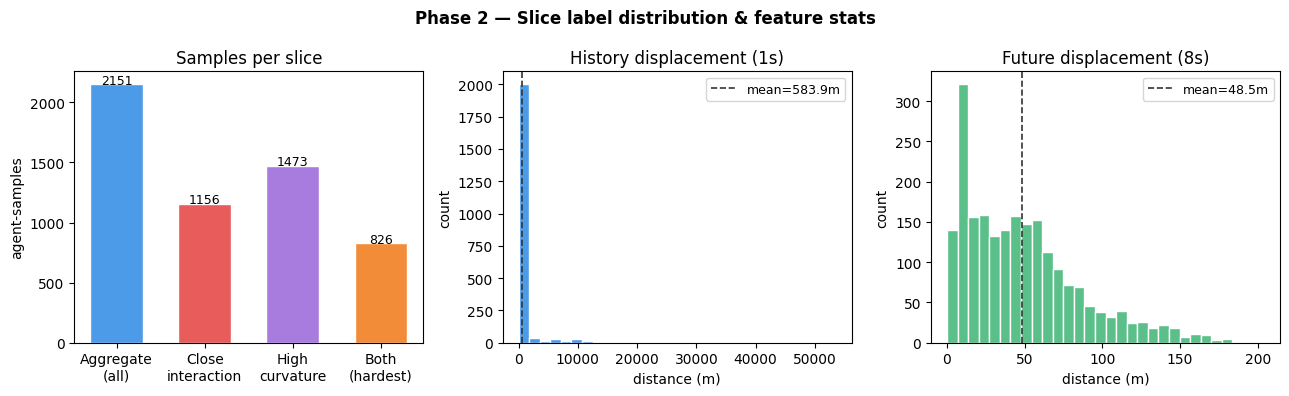

✅ Phase 2 data verified and plotted


In [ ]:
import matplotlib.pyplot as plt
import io
import numpy as np

# Redefine bucket reference
bucket = _gcs.bucket(GCS_BUCKET)

# Load all saved shards and verify
all_data = []
for b in sorted(bucket.list_blobs(prefix='features/val/'), key=lambda x: x.name):
    buf = io.BytesIO(b.download_as_bytes())
    d   = dict(np.load(buf, allow_pickle=True))
    all_data.append(d)

# Concatenate
data = {k: np.concatenate([d[k] for d in all_data], axis=0) for k in all_data[0].keys()}
N = len(data['scenario_id'])

print(f"Total agent-samples : {N}")
print(f"history_xy shape    : {data['history_xy'].shape}")
print(f"future_xy shape     : {data['future_xy'].shape}")
print(f"Close-int samples   : {data['label_close_int'].sum()} ({100*data['label_close_int'].mean():.1f}%)")
print(f"High-curv samples   : {data['label_high_curv'].sum()} ({100*data['label_high_curv'].mean():.1f}%)")
print()
# Plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Phase 2 — Slice label distribution & feature stats', fontsize=12, fontweight='bold')

# 1 — Slice breakdown
slices = {
    'Aggregate\n(all)': N,
    'Close\ninteraction': int(data['label_close_int'].sum()),
    'High\ncurvature':   int(data['label_high_curv'].sum()),
    'Both\n(hardest)':   int((data['label_close_int'] & data['label_high_curv']).sum()),
}
colors = ['#4C9BE8', '#E85C5C', '#A87CDE', '#F28C38']
axes[0].bar(slices.keys(), slices.values(), color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Samples per slice')
axes[0].set_ylabel('agent-samples')
for i, (k, v) in enumerate(slices.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# 2 — History trajectory displacement (how much agents move in 1s history)
hist_disp = np.linalg.norm(
    data['history_xy'][:, -1, :] - data['history_xy'][:, 0, :], axis=1
)
axes[1].hist(hist_disp, bins=30, color='#4C9BE8', edgecolor='white')
axes[1].set_title('History displacement (1s)')
axes[1].set_xlabel('distance (m)')
axes[1].set_ylabel('count')
axes[1].axvline(hist_disp.mean(), color='#333', lw=1.2, linestyle='--', label=f'mean={hist_disp.mean():.1f}m')
axes[1].legend(fontsize=9)

# 3 — Future trajectory displacement (ground truth horizon)
fut_valid = data['future_valid']
fut_xy    = data['future_xy']
last_valid_idx = np.array([
    np.where(v)[0][-1] if v.any() else 0
    for v in fut_valid
])
fut_disp = np.array([
    np.linalg.norm(fut_xy[i, last_valid_idx[i]])
    for i in range(N)
])
axes[2].hist(fut_disp, bins=30, color='#5BBF8A', edgecolor='white')
axes[2].set_title('Future displacement (8s)')
axes[2].set_xlabel('distance (m)')
axes[2].set_ylabel('count')
axes[2].axvline(fut_disp.mean(), color='#333', lw=1.2, linestyle='--', label=f'mean={fut_disp.mean():.1f}m')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/phase2_slices.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Phase 2 data verified and plotted")

# Phase 3 : Training CV + MLP + GRU baselines, first results table

In [ ]:
import numpy as np

def predict_constant_velocity(history_xy, history_valid, n_steps=80):
    """
    Extrapolate last observed velocity linearly for n_steps.
    Returns (n_steps, 2) predicted trajectory.
    """
    valid_idx = np.where(history_valid)[0]
    if len(valid_idx) < 2:
        # No motion info — stay at last known position
        last = history_xy[valid_idx[-1]] if len(valid_idx) > 0 else np.zeros(2)
        return np.tile(last, (n_steps, 1))

    # Velocity from last two valid steps (dt = 0.1s at 10Hz)
    p1 = history_xy[valid_idx[-2]]
    p2 = history_xy[valid_idx[-1]]
    vel = (p2 - p1) / 0.1   # m/s

    future = np.zeros((n_steps, 2), dtype=np.float32)
    for t in range(n_steps):
        future[t] = p2 + vel * (t + 1) * 0.1
    return future

print("✅ Constant velocity baseline defined")

✅ Constant velocity baseline defined


In [ ]:
def compute_ade(pred, gt, valid):
    """Average Displacement Error over valid future steps."""
    valid = valid.astype(bool)
    if not valid.any():
        return np.nan
    diff = np.linalg.norm(pred[valid] - gt[valid], axis=1)
    return diff.mean()

def compute_fde(pred, gt, valid):
    """Final Displacement Error at last valid future step."""
    valid_idx = np.where(valid)[0]
    if len(valid_idx) == 0:
        return np.nan
    last = valid_idx[-1]
    return np.linalg.norm(pred[last] - gt[last])

def evaluate_predictions(preds, data, slice_mask=None):
    """
    Evaluate ADE/FDE over a dataset slice.
    preds: (N, FUTURE_STEPS, 2)
    slice_mask: boolean array of shape (N,), None = all samples
    """
    if slice_mask is None:
        slice_mask = np.ones(len(preds), dtype=bool)

    ades, fdes = [], []
    for i in np.where(slice_mask)[0]:
        ade = compute_ade(preds[i], data['future_xy'][i], data['future_valid'][i])
        fde = compute_fde(preds[i], data['future_xy'][i], data['future_valid'][i])
        if not np.isnan(ade):
            ades.append(ade)
            fdes.append(fde)

    return {
        'ADE' : round(float(np.mean(ades)), 4),
        'FDE' : round(float(np.mean(fdes)), 4),
        'n'   : len(ades),
    }

print("✅ ADE/FDE metrics defined")

✅ ADE/FDE metrics defined


In [ ]:
N = len(data['history_xy'])

# Generate CV predictions for all samples
cv_preds = np.stack([
    predict_constant_velocity(data['history_xy'][i], data['history_valid'][i])
    for i in range(N)
])
print(f"CV predictions shape: {cv_preds.shape}")

# Evaluate on each slice
close_mask = data['label_close_int'].astype(bool)
curv_mask  = data['label_high_curv'].astype(bool)
both_mask  = close_mask & curv_mask

results_cv = {
    'Aggregate'         : evaluate_predictions(cv_preds, data),
    'Close-interaction' : evaluate_predictions(cv_preds, data, close_mask),
    'High-curvature'    : evaluate_predictions(cv_preds, data, curv_mask),
    'Both (hardest)'    : evaluate_predictions(cv_preds, data, both_mask),
}

print("\n=== Constant Velocity Baseline ===")
print(f"{'Slice':<22} {'ADE':>8} {'FDE':>8} {'N':>6}")
print("-" * 46)
for slice_name, m in results_cv.items():
    print(f"{slice_name:<22} {m['ADE']:>8.3f} {m['FDE']:>8.3f} {m['n']:>6}")

CV predictions shape: (2151, 80, 2)

=== Constant Velocity Baseline ===
Slice                       ADE      FDE      N
----------------------------------------------
Aggregate                 9.293   25.189   2151
Close-interaction         9.479   25.668   1156
High-curvature            9.015   24.265   1473
Both (hardest)            9.268   24.984    826


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class WOMDSliceDataset(Dataset):
    def __init__(self, data):
        self.history = torch.tensor(data['history_xy'],    dtype=torch.float32)
        self.hv      = torch.tensor(data['history_hv'],    dtype=torch.float32)
        self.valid_h = torch.tensor(data['history_valid'], dtype=torch.float32)
        self.future  = torch.tensor(data['future_xy'],     dtype=torch.float32)
        self.valid_f = torch.tensor(data['future_valid'],  dtype=torch.float32)

    def __len__(self): return len(self.history)

    def __getitem__(self, idx):
        # Flatten history features: xy + heading/vx/vy + valid mask
        hist_flat = torch.cat([
            self.history[idx].flatten(),   # 11*2 = 22
            self.hv[idx].flatten(),        # 11*3 = 33
            self.valid_h[idx],             # 11
        ])  # total: 66
        return hist_flat, self.future[idx], self.valid_f[idx]


class MLPBaseline(nn.Module):
    def __init__(self, input_dim=66, hidden=256, future_steps=80):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, future_steps * 2),
        )
        self.future_steps = future_steps

    def forward(self, x):
        return self.net(x).reshape(-1, self.future_steps, 2)


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

dataset    = WOMDSliceDataset(data)
loader     = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=2)
mlp_model  = MLPBaseline().to(device)
optimizer  = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

print(f"✅ MLP model: {sum(p.numel() for p in mlp_model.parameters()):,} parameters")
print(f"   Dataset  : {len(dataset)} samples")
print(f"   Batches  : {len(loader)} per epoch")

Device: cpu
✅ MLP model: 136,480 parameters
   Dataset  : 2151 samples
   Batches  : 9 per epoch


In [ ]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for hist_flat, fut_xy, fut_valid in loader:
        hist_flat = hist_flat.to(device)
        fut_xy    = fut_xy.to(device)
        fut_valid = fut_valid.to(device)

        pred = model(hist_flat)

        # ADE loss — only on valid future steps
        mask = fut_valid.unsqueeze(-1).expand_as(pred)
        loss = (torch.norm(pred - fut_xy, dim=-1) * fut_valid).sum() / (fut_valid.sum() + 1e-6)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


N_EPOCHS = 20
print(f"Training MLP for {N_EPOCHS} epochs...")
for epoch in range(N_EPOCHS):
    loss = train_epoch(mlp_model, loader, optimizer, device)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:>3}/{N_EPOCHS}  loss={loss:.4f}")

print("✅ MLP training complete")

Training MLP for 20 epochs...
  Epoch   5/20  loss=24.1299
  Epoch  10/20  loss=17.3543
  Epoch  15/20  loss=11.7660
  Epoch  20/20  loss=11.5231
✅ MLP training complete


In [ ]:
class GRUBaseline(nn.Module):
    def __init__(self, input_dim=5, hidden=128, future_steps=80):
        super().__init__()
        # input per step: x, y, heading, vx, vy
        self.gru  = nn.GRU(input_dim, hidden, num_layers=2,
                           batch_first=True, dropout=0.1)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, future_steps * 2),
        )
        self.future_steps = future_steps

    def forward(self, hist_xy, hist_hv):
        # hist_xy: (B, 11, 2)  hist_hv: (B, 11, 3)
        x = torch.cat([hist_xy, hist_hv], dim=-1)  # (B, 11, 5)
        _, h = self.gru(x)
        return self.head(h[-1]).reshape(-1, self.future_steps, 2)


class WOMDSliceDatasetGRU(Dataset):
    def __init__(self, data):
        self.history_xy = torch.tensor(data['history_xy'],    dtype=torch.float32)
        self.history_hv = torch.tensor(data['history_hv'],    dtype=torch.float32)
        self.future     = torch.tensor(data['future_xy'],     dtype=torch.float32)
        self.valid_f    = torch.tensor(data['future_valid'],  dtype=torch.float32)

    def __len__(self): return len(self.history_xy)
    def __getitem__(self, idx):
        return self.history_xy[idx], self.history_hv[idx], self.future[idx], self.valid_f[idx]


gru_dataset = WOMDSliceDatasetGRU(data)
gru_loader  = DataLoader(gru_dataset, batch_size=256, shuffle=True, num_workers=2)
gru_model   = GRUBaseline().to(device)
gru_optim   = torch.optim.Adam(gru_model.parameters(), lr=1e-3)

print(f"✅ GRU model: {sum(p.numel() for p in gru_model.parameters()):,} parameters")

# Train
for epoch in range(N_EPOCHS):
    gru_model.train()
    total_loss = 0
    for hxy, hhv, fut_xy, fut_valid in gru_loader:
        hxy, hhv = hxy.to(device), hhv.to(device)
        fut_xy, fut_valid = fut_xy.to(device), fut_valid.to(device)
        pred = gru_model(hxy, hhv)
        loss = (torch.norm(pred - fut_xy, dim=-1) * fut_valid).sum() / (fut_valid.sum() + 1e-6)
        gru_optim.zero_grad(); loss.backward(); gru_optim.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:>3}/{N_EPOCHS}  loss={total_loss/len(gru_loader):.4f}")

print("✅ GRU training complete")

✅ GRU model: 188,064 parameters
  Epoch   5/20  loss=19.1937
  Epoch  10/20  loss=12.5345
  Epoch  15/20  loss=9.7166
  Epoch  20/20  loss=8.5989
✅ GRU training complete


In [ ]:
def get_predictions_mlp(model, data, device):
    model.eval()
    dataset = WOMDSliceDataset(data)
    loader  = DataLoader(dataset, batch_size=512, shuffle=False)
    preds   = []
    with torch.no_grad():
        for hist_flat, _, _ in loader:
            preds.append(model(hist_flat.to(device)).cpu().numpy())
    return np.concatenate(preds)

def get_predictions_gru(model, data, device):
    model.eval()
    dataset = WOMDSliceDatasetGRU(data)
    loader  = DataLoader(dataset, batch_size=512, shuffle=False)
    preds   = []
    with torch.no_grad():
        for hxy, hhv, _, _ in loader:
            preds.append(model(hxy.to(device), hhv.to(device)).cpu().numpy())
    return np.concatenate(preds)

mlp_preds = get_predictions_mlp(mlp_model, data, device)
gru_preds = get_predictions_gru(gru_model, data, device)

# Full comparison table
slices = {
    'Aggregate'         : None,
    'Close-interaction' : close_mask,
    'High-curvature'    : curv_mask,
    'Both (hardest)'    : both_mask,
}

print(f"\n{'Slice':<22} {'Model':<8} {'ADE':>8} {'FDE':>8} {'N':>6}")
print("=" * 56)
for slice_name, mask in slices.items():
    for model_name, preds in [('CV', cv_preds), ('MLP', mlp_preds), ('GRU', gru_preds)]:
        m = evaluate_predictions(preds, data, mask)
        print(f"{slice_name:<22} {model_name:<8} {m['ADE']:>8.3f} {m['FDE']:>8.3f} {m['n']:>6}")
    print("-" * 56)


Slice                  Model         ADE      FDE      N
Aggregate              CV          9.293   25.189   2151
Aggregate              MLP        11.402   27.830   2151
Aggregate              GRU         8.415   23.166   2151
--------------------------------------------------------
Close-interaction      CV          9.479   25.668   1156
Close-interaction      MLP        11.249   27.770   1156
Close-interaction      GRU         8.393   23.320   1156
--------------------------------------------------------
High-curvature         CV          9.015   24.265   1473
High-curvature         MLP        10.855   26.655   1473
High-curvature         GRU         8.063   22.062   1473
--------------------------------------------------------
Both (hardest)         CV          9.268   24.984    826
Both (hardest)         MLP        10.980   27.213    826
Both (hardest)         GRU         8.165   22.636    826
--------------------------------------------------------


# Phase 3.5 : more data, normalization, better models

In [ ]:
import io, numpy as np, tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2
from tqdm import tqdm

HIST_STEPS   = 11
FUTURE_STEPS = 80
N_SHARDS     = 50   # up from 5
MAX_SCENARIOS = 200  # up from 100

def extract_features_normalized(scenario) -> list:
    records = []
    for req in scenario.tracks_to_predict:
        track  = scenario.tracks[req.track_index]
        states = track.states

        hist_xy    = np.zeros((HIST_STEPS, 2),   dtype=np.float32)
        hist_hv    = np.zeros((HIST_STEPS, 3),   dtype=np.float32)
        hist_valid = np.zeros((HIST_STEPS,),      dtype=bool)
        fut_xy     = np.zeros((FUTURE_STEPS, 2), dtype=np.float32)
        fut_valid  = np.zeros((FUTURE_STEPS,),    dtype=bool)

        for t in range(HIST_STEPS):
            if t < len(states) and states[t].valid:
                st = states[t]
                hist_xy[t]    = [st.center_x, st.center_y]
                hist_hv[t]    = [st.heading, st.velocity_x, st.velocity_y]
                hist_valid[t] = True

        for t in range(FUTURE_STEPS):
            idx = HIST_STEPS + t
            if idx < len(states) and states[idx].valid:
                st = states[idx]
                fut_xy[t]    = [st.center_x, st.center_y]
                fut_valid[t] = True

        # ── Normalization ──────────────────────────────────────────────
        # Origin: last valid history position
        origin = hist_xy[hist_valid][-1] if hist_valid.any() else np.zeros(2)

        # Heading at last valid step → rotate everything to ego frame
        last_heading = hist_hv[hist_valid][-1, 0] if hist_valid.any() else 0.0
        cos_h, sin_h = np.cos(-last_heading), np.sin(-last_heading)
        R = np.array([[cos_h, -sin_h], [sin_h, cos_h]], dtype=np.float32)

        # Translate then rotate
        hist_xy_norm = (hist_xy - origin) @ R.T
        fut_xy_norm  = (fut_xy  - origin) @ R.T

        # Normalize velocities by typical speed (10 m/s)
        hist_hv_norm = hist_hv.copy()
        hist_hv_norm[:, 1:] /= 10.0  # vx, vy → [-1, 1] approx
        # Zero out invalid steps
        hist_xy_norm[~hist_valid] = 0.0
        fut_xy_norm[~fut_valid]   = 0.0

        records.append({
            'scenario_id'   : scenario.scenario_id,
            'track_index'   : req.track_index,
            'agent_type'    : AGENT_TYPE_INT.get(track.object_type, 3),
            'history_xy'    : hist_xy_norm,
            'history_hv'    : hist_hv_norm,
            'history_valid' : hist_valid,
            'future_xy'     : fut_xy_norm,
            'future_valid'  : fut_valid,
            'origin'        : origin,
            'heading'       : np.float32(last_heading),
        })
    return records


all_stats = {'total': 0, 'close_int': 0, 'high_curv': 0, 'both': 0}
bucket = _gcs.bucket(GCS_BUCKET)

for i, shard_blob in enumerate(tqdm(val_shards[:N_SHARDS], desc='Shards')):
    shard_path   = f"gs://{WOMD_BUCKET}/{shard_blob.name}"
    dataset      = tf.data.TFRecordDataset(shard_path, compression_type='')
    shard_feats  = []
    shard_labels = []

    for j, raw in enumerate(dataset):
        if j >= MAX_SCENARIOS:
            break
        sc = scenario_pb2.Scenario()
        sc.ParseFromString(raw.numpy())

        is_close = slice_close_interaction(sc)
        is_curv  = slice_high_curvature(sc)

        for f in extract_features_normalized(sc):
            shard_feats.append(f)
            shard_labels.append({'close_int': is_close, 'high_curv': is_curv})

        all_stats['total']     += 1
        all_stats['close_int'] += int(is_close)
        all_stats['high_curv'] += int(is_curv)
        all_stats['both']      += int(is_close and is_curv)

    # Save shard
    arrays = {
        'scenario_id'    : np.array([f['scenario_id']    for f in shard_feats]),
        'track_index'    : np.array([f['track_index']    for f in shard_feats]),
        'agent_type'     : np.array([f['agent_type']     for f in shard_feats]),
        'history_xy'     : np.stack([f['history_xy']     for f in shard_feats]),
        'history_hv'     : np.stack([f['history_hv']     for f in shard_feats]),
        'history_valid'  : np.stack([f['history_valid']  for f in shard_feats]),
        'future_xy'      : np.stack([f['future_xy']      for f in shard_feats]),
        'future_valid'   : np.stack([f['future_valid']   for f in shard_feats]),
        'origin'         : np.stack([f['origin']         for f in shard_feats]),
        'heading'        : np.array([f['heading']        for f in shard_feats]),
        'label_close_int': np.array([l['close_int']      for l in shard_labels]),
        'label_high_curv': np.array([l['high_curv']      for l in shard_labels]),
    }
    buf = io.BytesIO()
    np.savez_compressed(buf, **arrays)
    buf.seek(0)
    blob = bucket.blob(f'features/val_v2/shard_{i:04d}.npz')
    blob.upload_from_file(buf, content_type='application/octet-stream')

print(f"\n✅ Done — {N_SHARDS} shards processed")
print(f"   Scenarios : {all_stats['total']:,}")
print(f"   Close-int : {all_stats['close_int']:,} ({100*all_stats['close_int']/all_stats['total']:.1f}%)")
print(f"   High-curv : {all_stats['high_curv']:,} ({100*all_stats['high_curv']/all_stats['total']:.1f}%)")
print(f"   Both      : {all_stats['both']:,} ({100*all_stats['both']/all_stats['total']:.1f}%)")

Shards: 100%|██████████| 50/50 [04:53<00:00,  5.87s/it]


✅ Done — 50 shards processed
   Scenarios : 10,000
   Close-int : 3,892 (38.9%)
   High-curv : 5,947 (59.5%)
   Both      : 2,643 (26.4%)


# Phase 4 : Model Retraining

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import io, numpy as np
from google.cloud import storage

# ── Reload the 50-shard data ──────────────────────────────────────────────
PROJECT_ID = 'womd-imitation'
GCS_BUCKET = 'womd-imitation-data'
_gcs = storage.Client(project=PROJECT_ID)
bucket = _gcs.bucket(GCS_BUCKET)

print("Loading 50-shard data from GCS...")
all_data = []
for b in sorted(bucket.list_blobs(prefix='features/val_v2/'), key=lambda x: x.name):
    buf = io.BytesIO(b.download_as_bytes())
    all_data.append(dict(np.load(buf, allow_pickle=True)))

data = {k: np.concatenate([d[k] for d in all_data]) for k in all_data[0]}
N = len(data['history_xy'])
print(f"✅ Loaded {N:,} agent-samples")

# ── Dataset ───────────────────────────────────────────────────────────────
class WOMDDataset(Dataset):
    def __init__(self, data):
        self.hxy  = torch.tensor(data['history_xy'],    dtype=torch.float32)
        self.hhv  = torch.tensor(data['history_hv'],    dtype=torch.float32)
        self.hval = torch.tensor(data['history_valid'], dtype=torch.float32)
        self.fxy  = torch.tensor(data['future_xy'],     dtype=torch.float32)
        self.fval = torch.tensor(data['future_valid'],  dtype=torch.float32)
    def __len__(self): return len(self.hxy)
    def __getitem__(self, i):
        flat = torch.cat([self.hxy[i].flatten(), self.hhv[i].flatten(), self.hval[i]])
        return flat, self.hxy[i], self.hhv[i], self.fxy[i], self.fval[i]

device  = 'cuda' if torch.cuda.is_available() else 'cpu'
dataset = WOMDDataset(data)
loader  = DataLoader(dataset, batch_size=512, shuffle=True, num_workers=2, pin_memory=True)
print(f"Device : {device}")
print(f"Batches: {len(loader)} per epoch")

# ── Models ────────────────────────────────────────────────────────────────
class MLPModel(nn.Module):
    def __init__(self, inp=66, hidden=512, out_steps=80):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inp, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, hidden//2), nn.GELU(),
            nn.Linear(hidden//2, out_steps * 2),
        )
        self.out_steps = out_steps
    def forward(self, flat, hxy, hhv):
        return self.net(flat).reshape(-1, self.out_steps, 2)

class GRUModel(nn.Module):
    def __init__(self, inp=5, hidden=512, out_steps=80):
        super().__init__()
        self.gru  = nn.GRU(inp, hidden, num_layers=3, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, hidden//2), nn.GELU(),
            nn.Linear(hidden//2, out_steps * 2),
        )
        self.out_steps = out_steps
    def forward(self, flat, hxy, hhv):
        x = torch.cat([hxy, hhv], dim=-1)
        _, h = self.gru(x)
        return self.head(h[-1]).reshape(-1, self.out_steps, 2)

def train_model(model, loader, n_epochs=100, label=''):
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    best_loss = float('inf')
    for epoch in range(n_epochs):
        model.train()
        total = 0
        for flat, hxy, hhv, fxy, fval in loader:
            flat, hxy, hhv = flat.to(device), hxy.to(device), hhv.to(device)
            fxy, fval = fxy.to(device), fval.to(device)
            pred = model(flat, hxy, hhv)
            loss = (torch.norm(pred - fxy, dim=-1) * fval).sum() / (fval.sum() + 1e-6)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item()
        scheduler.step()
        avg = total / len(loader)
        if avg < best_loss:
            best_loss = avg
            torch.save(model.state_dict(), f'/tmp/best_{label}.pt')
        if (epoch+1) % 10 == 0:
            print(f"  [{label}] Epoch {epoch+1:>3}/100  loss={avg:.4f}  best={best_loss:.4f}")
    return best_loss

# ── Train GRU ─────────────────────────────────────────────────────────────
print("\nTraining GRU (512-hidden, 3-layer, 100 epochs)...")
gru = GRUModel(hidden=512).to(device)
print(f"  Parameters: {sum(p.numel() for p in gru.parameters()):,}")
gru_best = train_model(gru, loader, n_epochs=100, label='gru')

# ── Train MLP ─────────────────────────────────────────────────────────────
print("\nTraining MLP (512-hidden, 100 epochs)...")
mlp = MLPModel(hidden=512).to(device)
print(f"  Parameters: {sum(p.numel() for p in mlp.parameters()):,}")
mlp_best = train_model(mlp, loader, n_epochs=100, label='mlp')

print(f"\n✅ Training complete")
print(f"   GRU best loss: {gru_best:.4f}")
print(f"   MLP best loss: {mlp_best:.4f}")

# ── Save checkpoints to GCS ───────────────────────────────────────────────
for name in ['gru', 'mlp']:
    blob = bucket.blob(f'checkpoints/{name}_512_100ep.pt')
    blob.upload_from_filename(f'/tmp/best_{name}.pt')
    print(f"   Saved → gs://{GCS_BUCKET}/checkpoints/{name}_512_100ep.pt")

Loading 50-shard data from GCS...
✅ Loaded 43,278 agent-samples
Device : cuda
Batches: 85 per epoch

Training GRU (512-hidden, 3-layer, 100 epochs)...
  Parameters: 4,385,184
  [gru] Epoch  10/100  loss=7.7835  best=7.7835
  [gru] Epoch  20/100  loss=6.7249  best=6.7249
  [gru] Epoch  30/100  loss=6.1613  best=6.1613
  [gru] Epoch  40/100  loss=6.0169  best=6.0169
  [gru] Epoch  50/100  loss=5.8734  best=5.8436
  [gru] Epoch  60/100  loss=5.7883  best=5.7623
  [gru] Epoch  70/100  loss=5.6403  best=5.6403
  [gru] Epoch  80/100  loss=5.5596  best=5.5596
  [gru] Epoch  90/100  loss=5.4945  best=5.4945
  [gru] Epoch 100/100  loss=5.4935  best=5.4769

Training MLP (512-hidden, 100 epochs)...
  Parameters: 471,456
  [mlp] Epoch  10/100  loss=6.6514  best=6.6514
  [mlp] Epoch  20/100  loss=6.3347  best=6.3347
  [mlp] Epoch  30/100  loss=6.1248  best=6.1248
  [mlp] Epoch  40/100  loss=5.9795  best=5.9795
  [mlp] Epoch  50/100  loss=5.8905  best=5.8905
  [mlp] Epoch  60/100  loss=5.7770  best=

# Phase 5 : Model Comparison

In [1]:
from google.colab import auth
auth.authenticate_user()

import io, numpy as np, torch, torch.nn as nn
from google.cloud import storage
from torch.utils.data import Dataset, DataLoader

PROJECT_ID = 'womd-imitation'
GCS_BUCKET = 'womd-imitation-data'
WOMD_BUCKET = 'waymo_open_dataset_motion_v_1_3_1'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

_gcs   = storage.Client(project=PROJECT_ID)
bucket = _gcs.bucket(GCS_BUCKET)

# Load eval data
print("Loading eval data...")
all_data = []
for b in sorted(bucket.list_blobs(prefix='features/val_v2/'), key=lambda x: x.name):
    buf = io.BytesIO(b.download_as_bytes())
    all_data.append(dict(np.load(buf, allow_pickle=True)))

data = {k: np.concatenate([d[k] for d in all_data]) for k in all_data[0]}
N = len(data['history_xy'])

close_mask = data['label_close_int'].astype(bool)
curv_mask  = data['label_high_curv'].astype(bool)
both_mask  = close_mask & curv_mask

print(f"✅ Loaded {N:,} samples")
print(f"   Close-int : {close_mask.sum():,} ({100*close_mask.mean():.1f}%)")
print(f"   High-curv : {curv_mask.sum():,} ({100*curv_mask.mean():.1f}%)")
print(f"   Both      : {both_mask.sum():,} ({100*both_mask.mean():.1f}%)")

Loading eval data...
✅ Loaded 43,278 samples
   Close-int : 21,395 (49.4%)
   High-curv : 29,534 (68.2%)
   Both      : 15,391 (35.6%)


In [2]:
class MLPModel(nn.Module):
    def __init__(self, inp=66, hidden=512, out_steps=80):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inp, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, hidden//2), nn.GELU(),
            nn.Linear(hidden//2, out_steps * 2),
        )
        self.out_steps = out_steps
    def forward(self, flat, hxy, hhv):
        return self.net(flat).reshape(-1, self.out_steps, 2)

class GRUModel(nn.Module):
    def __init__(self, inp=5, hidden=512, out_steps=80):
        super().__init__()
        self.gru  = nn.GRU(inp, hidden, num_layers=3, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, hidden//2), nn.GELU(),
            nn.Linear(hidden//2, out_steps * 2),
        )
        self.out_steps = out_steps
    def forward(self, flat, hxy, hhv):
        x = torch.cat([hxy, hhv], dim=-1)
        _, h = self.gru(x)
        return self.head(h[-1]).reshape(-1, self.out_steps, 2)

def load_checkpoint(model, gcs_path):
    blob = bucket.blob(gcs_path)
    buf  = io.BytesIO(blob.download_as_bytes())
    model.load_state_dict(torch.load(buf, map_location=device))
    model.eval()
    return model

gru = load_checkpoint(GRUModel(hidden=512).to(device), 'checkpoints/gru_512_100ep.pt')
mlp = load_checkpoint(MLPModel(hidden=512).to(device), 'checkpoints/mlp_512_100ep.pt')
print("✅ Checkpoints loaded")

✅ Checkpoints loaded


In [3]:
def predict_cv(history_xy, history_valid, n_steps=80):
    valid_idx = np.where(history_valid)[0]
    if len(valid_idx) < 2:
        last = history_xy[valid_idx[-1]] if len(valid_idx) > 0 else np.zeros(2)
        return np.tile(last, (n_steps, 1))
    p1  = history_xy[valid_idx[-2]]
    p2  = history_xy[valid_idx[-1]]
    vel = (p2 - p1) / 0.1
    return np.array([p2 + vel * (t+1) * 0.1 for t in range(n_steps)], dtype=np.float32)

def get_preds_nn(model, data, device, is_gru=True):
    class _DS(Dataset):
        def __init__(self, d):
            self.hxy  = torch.tensor(d['history_xy'],    dtype=torch.float32)
            self.hhv  = torch.tensor(d['history_hv'],    dtype=torch.float32)
            self.hval = torch.tensor(d['history_valid'], dtype=torch.float32)
        def __len__(self): return len(self.hxy)
        def __getitem__(self, i):
            flat = torch.cat([self.hxy[i].flatten(), self.hhv[i].flatten(), self.hval[i]])
            return flat, self.hxy[i], self.hhv[i]

    loader = DataLoader(_DS(data), batch_size=1024, shuffle=False)
    preds  = []
    with torch.no_grad():
        for flat, hxy, hhv in loader:
            flat, hxy, hhv = flat.to(device), hxy.to(device), hhv.to(device)
            preds.append(model(flat, hxy, hhv).cpu().numpy())
    return np.concatenate(preds)

def evaluate(preds, data, mask=None):
    if mask is None:
        mask = np.ones(len(preds), dtype=bool)
    ades, fdes = [], []
    for i in np.where(mask)[0]:
        valid = data['future_valid'][i].astype(bool)
        if not valid.any(): continue
        diff = np.linalg.norm(preds[i] - data['future_xy'][i], axis=1)
        ades.append(diff[valid].mean())
        fdes.append(diff[np.where(valid)[0][-1]])
    return {'ADE': round(np.mean(ades), 3),
            'FDE': round(np.mean(fdes), 3),
            'N'  : len(ades)}

# Generate all predictions
print("Generating predictions...")
cv_preds  = np.stack([predict_cv(data['history_xy'][i], data['history_valid'][i]) for i in range(N)])
gru_preds = get_preds_nn(gru, data, device, is_gru=True)
mlp_preds = get_preds_nn(mlp, data, device, is_gru=False)
print("✅ Predictions generated")

# Full results table
slices = {
    'Aggregate'        : None,
    'Close-interaction': close_mask,
    'High-curvature'   : curv_mask,
    'Both (hardest)'   : both_mask,
}

print(f"\n{'Slice':<22} {'Model':<8} {'ADE':>7} {'FDE':>7} {'N':>6}")
print("=" * 52)
all_results = {}
for sname, mask in slices.items():
    row = {}
    for mname, preds in [('CV', cv_preds), ('MLP', mlp_preds), ('GRU', gru_preds)]:
        m = evaluate(preds, data, mask)
        row[mname] = m
        print(f"{sname:<22} {mname:<8} {m['ADE']:>7.3f} {m['FDE']:>7.3f} {m['N']:>6}")
    all_results[sname] = row
    print("-" * 52)

Generating predictions...
✅ Predictions generated

Slice                  Model        ADE     FDE      N
Aggregate              CV         9.349  25.425  43278
Aggregate              MLP        5.399  15.753  43278
Aggregate              GRU        5.280  15.405  43278
----------------------------------------------------
Close-interaction      CV         8.981  24.478  21395
Close-interaction      MLP        5.358  15.628  21395
Close-interaction      GRU        5.268  15.372  21395
----------------------------------------------------
High-curvature         CV         9.131  24.746  29534
High-curvature         MLP        5.272  15.335  29534
High-curvature         GRU        5.165  15.009  29534
----------------------------------------------------
Both (hardest)         CV         8.749  23.759  15391
Both (hardest)         MLP        5.228  15.191  15391
Both (hardest)         GRU        5.144  14.941  15391
----------------------------------------------------


✅ Results saved to gs://womd-imitation-data/results/final_eval.json
✅ Plot saved to gs://womd-imitation-data/plots/final_results.png


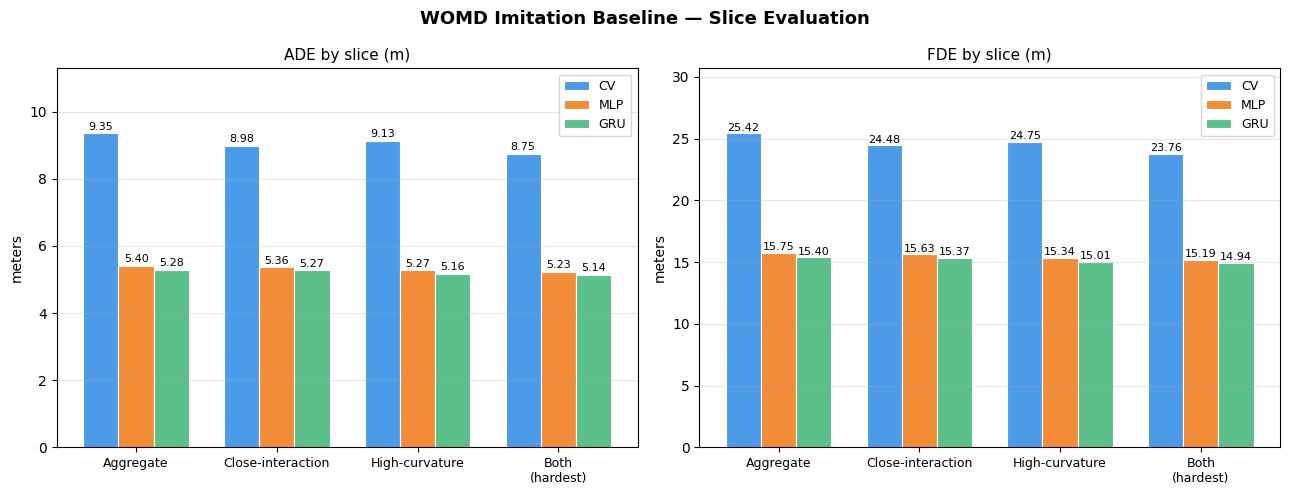

In [5]:
import matplotlib.pyplot as plt
import json
import numpy as np

# Fix: convert numpy types to native Python before JSON serialization
def to_serializable(obj):
    if isinstance(obj, (np.float32, np.float64)): return float(obj)
    if isinstance(obj, (np.int32, np.int64)):     return int(obj)
    if isinstance(obj, dict):  return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):  return [to_serializable(v) for v in obj]
    return obj

# Save results JSON to GCS
results_json = json.dumps(to_serializable(all_results), indent=2)
bucket.blob('results/final_eval.json').upload_from_string(results_json)
print("✅ Results saved to gs://womd-imitation-data/results/final_eval.json")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('WOMD Imitation Baseline — Slice Evaluation', fontsize=13, fontweight='bold')

slice_names = list(all_results.keys())
model_names = ['CV', 'MLP', 'GRU']
colors      = ['#4C9BE8', '#F28C38', '#5BBF8A']
x           = np.arange(len(slice_names))
width       = 0.25

for ax, metric in zip(axes, ['ADE', 'FDE']):
    for i, (mname, color) in enumerate(zip(model_names, colors)):
        vals = [float(all_results[s][mname][metric]) for s in slice_names]
        bars = ax.bar(x + i*width, vals, width, label=mname,
                      color=color, edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{metric} by slice (m)', fontsize=11)
    ax.set_xticks(x + width)
    ax.set_xticklabels([s.replace(' ', '\n') for s in slice_names], fontsize=9)
    ax.set_ylabel('meters')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.savefig('/tmp/final_results.png', dpi=150, bbox_inches='tight')
bucket.blob('plots/final_results.png').upload_from_filename('/tmp/final_results.png')
print("✅ Plot saved to gs://womd-imitation-data/plots/final_results.png")
plt.show()

SyntaxError: invalid syntax (2795544704.py, line 1)

# Phase 6: Albatations

In [10]:
from google.colab import auth
auth.authenticate_user()

import io, numpy as np, tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2
from google.cloud import storage
from tqdm import tqdm

PROJECT_ID  = 'womd-imitation'
GCS_BUCKET  = 'womd-imitation-data'
WOMD_BUCKET = 'waymo_open_dataset_motion_v_1_3_1'

_gcs        = storage.Client(project=PROJECT_ID)
bucket      = _gcs.bucket(GCS_BUCKET)
womd_bucket = _gcs.bucket(WOMD_BUCKET)

val_blobs  = list(womd_bucket.list_blobs(prefix='uncompressed/scenario/validation/'))
val_shards = [b for b in val_blobs if 'tfrecord' in b.name]
print(f"✅ Ready — {len(val_shards)} val shards found")

AGENT_TYPE_INT = {
    scenario_pb2.Track.TYPE_VEHICLE    : 0,
    scenario_pb2.Track.TYPE_PEDESTRIAN : 1,
    scenario_pb2.Track.TYPE_CYCLIST    : 2,
    scenario_pb2.Track.TYPE_OTHER      : 3,
    scenario_pb2.Track.TYPE_UNSET      : 3,
}

def extract_with_history(scenario, hist_steps, future_steps=80):
    records = []
    for req in scenario.tracks_to_predict:
        track  = scenario.tracks[req.track_index]
        states = track.states

        hist_xy    = np.zeros((hist_steps, 2),    dtype=np.float32)
        hist_hv    = np.zeros((hist_steps, 3),    dtype=np.float32)
        hist_valid = np.zeros((hist_steps,),       dtype=bool)
        fut_xy     = np.zeros((future_steps, 2),  dtype=np.float32)
        fut_valid  = np.zeros((future_steps,),     dtype=bool)

        for t in range(hist_steps):
            if t < len(states) and states[t].valid:
                st = states[t]
                hist_xy[t]    = [st.center_x, st.center_y]
                hist_hv[t]    = [st.heading, st.velocity_x, st.velocity_y]
                hist_valid[t] = True

        for t in range(future_steps):
            idx = hist_steps + t
            if idx < len(states) and states[idx].valid:
                st = states[idx]
                fut_xy[t]    = [st.center_x, st.center_y]
                fut_valid[t] = True

        # Normalize to ego frame
        origin      = hist_xy[hist_valid][-1] if hist_valid.any() else np.zeros(2)
        last_heading= hist_hv[hist_valid][-1, 0] if hist_valid.any() else 0.0
        cos_h, sin_h = np.cos(-last_heading), np.sin(-last_heading)
        R = np.array([[cos_h, -sin_h],[sin_h, cos_h]], dtype=np.float32)

        hist_xy_norm          = (hist_xy - origin) @ R.T
        fut_xy_norm           = (fut_xy  - origin) @ R.T
        hist_xy_norm[~hist_valid] = 0.0
        fut_xy_norm[~fut_valid]   = 0.0
        hist_hv_norm          = hist_hv.copy()
        hist_hv_norm[:, 1:]  /= 10.0

        records.append({
            'history_xy'   : hist_xy_norm,
            'history_hv'   : hist_hv_norm,
            'history_valid': hist_valid,
            'future_xy'    : fut_xy_norm,
            'future_valid' : fut_valid,
            'agent_type'   : AGENT_TYPE_INT.get(track.object_type, 3),
            'scenario_id'  : scenario.scenario_id,
        })
    return records

def slice_close_interaction(scenario, threshold_m=5.0):
    pred_tracks = [scenario.tracks[t.track_index] for t in scenario.tracks_to_predict]
    if len(pred_tracks) < 2: return False
    for i in range(len(pred_tracks)):
        for j in range(i+1, len(pred_tracks)):
            si, sj = pred_tracks[i].states, pred_tracks[j].states
            for k in range(min(len(si), len(sj))):
                if si[k].valid and sj[k].valid:
                    dx = si[k].center_x - sj[k].center_x
                    dy = si[k].center_y - sj[k].center_y
                    if (dx*dx + dy*dy)**0.5 < threshold_m: return True
    return False

def slice_high_curvature(scenario, radius_thresh_m=20.0):
    for req in scenario.tracks_to_predict:
        track  = scenario.tracks[req.track_index]
        states = track.states[:11]
        for k in range(1, len(states)-1):
            if not (states[k-1].valid and states[k].valid and states[k+1].valid): continue
            speed = (states[k].velocity_x**2 + states[k].velocity_y**2)**0.5
            if speed < 1.0: continue
            dh = states[k].heading - states[k-1].heading
            dh = (dh + np.pi) % (2*np.pi) - np.pi
            heading_rate = abs(dh) / 0.1
            if heading_rate < 1e-3: continue
            if speed / heading_rate < radius_thresh_m: return True
    return False

# ── Extract for hist=3s (31 steps) and hist=5s (51 steps) ─────────────────
N_SHARDS     = 50
MAX_SCENARIOS = 200

for hist_steps, hist_label in [(31, '3s'), (51, '5s')]:
    print(f"\nExtracting history={hist_label} ({hist_steps} steps)...")
    for i, shard_blob in enumerate(tqdm(val_shards[:N_SHARDS], desc=f'hist={hist_label}')):
        shard_path   = f"gs://{WOMD_BUCKET}/{shard_blob.name}"
        dataset      = tf.data.TFRecordDataset(shard_path, compression_type='')
        shard_feats  = []
        shard_labels = []

        for j, raw in enumerate(dataset):
            if j >= MAX_SCENARIOS: break
            sc = scenario_pb2.Scenario()
            sc.ParseFromString(raw.numpy())
            is_close = slice_close_interaction(sc)
            is_curv  = slice_high_curvature(sc)
            for f in extract_with_history(sc, hist_steps):
                shard_feats.append(f)
                shard_labels.append({'close_int': is_close, 'high_curv': is_curv})

        if not shard_feats: continue
        arrays = {
            'history_xy'    : np.stack([f['history_xy']     for f in shard_feats]),
            'history_hv'    : np.stack([f['history_hv']     for f in shard_feats]),
            'history_valid' : np.stack([f['history_valid']  for f in shard_feats]),
            'future_xy'     : np.stack([f['future_xy']      for f in shard_feats]),
            'future_valid'  : np.stack([f['future_valid']   for f in shard_feats]),
            'label_close_int': np.array([l['close_int']     for l in shard_labels]),
            'label_high_curv': np.array([l['high_curv']     for l in shard_labels]),
        }
        buf = io.BytesIO()
        np.savez_compressed(buf, **arrays)
        buf.seek(0)
        bucket.blob(f'features/ablation_hist_{hist_label}/shard_{i:04d}.npz').upload_from_file(
            buf, content_type='application/octet-stream')

print("\n✅ Feature extraction for history ablation complete")

✅ Ready — 150 val shards found

Extracting history=3s (31 steps)...


hist=3s: 100%|██████████| 50/50 [06:54<00:00,  8.29s/it]



Extracting history=5s (51 steps)...


hist=5s: 100%|██████████| 50/50 [05:33<00:00,  6.68s/it]


✅ Feature extraction for history ablation complete


In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

class GRUModel(nn.Module):
    def __init__(self, hist_steps, hidden=256, out_steps=80):
        super().__init__()
        self.gru  = nn.GRU(5, hidden, num_layers=2, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_steps * 2)
        )
        self.out_steps = out_steps
    def forward(self, hxy, hhv):
        x = torch.cat([hxy, hhv], dim=-1)
        _, h = self.gru(x)
        return self.head(h[-1]).reshape(-1, self.out_steps, 2)

class AblationDataset(Dataset):
    def __init__(self, data):
        self.hxy  = torch.tensor(data['history_xy'],    dtype=torch.float32)
        self.hhv  = torch.tensor(data['history_hv'],    dtype=torch.float32)
        self.fxy  = torch.tensor(data['future_xy'],     dtype=torch.float32)
        self.fval = torch.tensor(data['future_valid'],  dtype=torch.float32)
    def __len__(self): return len(self.hxy)
    def __getitem__(self, i):
        return self.hxy[i], self.hhv[i], self.fxy[i], self.fval[i]

def load_prefix(prefix):
    all_data = []
    for b in sorted(bucket.list_blobs(prefix=prefix), key=lambda x: x.name):
        buf = io.BytesIO(b.download_as_bytes())
        all_data.append(dict(np.load(buf, allow_pickle=True)))
    return {k: np.concatenate([d[k] for d in all_data]) for k in all_data[0]}

def train_and_eval(data, hist_steps, n_epochs=60):
    ds     = AblationDataset(data)
    loader = DataLoader(ds, batch_size=512, shuffle=True, num_workers=2, pin_memory=True)
    model  = GRUModel(hist_steps).to(device)
    optim  = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=n_epochs)

    best_loss = float('inf')
    for epoch in range(n_epochs):
        model.train()
        total = 0
        for hxy, hhv, fxy, fval in loader:
            hxy, hhv   = hxy.to(device), hhv.to(device)
            fxy, fval  = fxy.to(device), fval.to(device)
            pred = model(hxy, hhv)
            loss = (torch.norm(pred - fxy, dim=-1) * fval).sum() / (fval.sum() + 1e-6)
            optim.zero_grad(); loss.backward(); optim.step()
            total += loss.item()
        sched.step()
        avg = total / len(loader)
        if avg < best_loss: best_loss = avg
        if (epoch+1) % 20 == 0:
            print(f"  epoch {epoch+1}/{n_epochs}  loss={avg:.4f}")
    return model

def evaluate_model(model, data):
    ds     = AblationDataset(data)
    loader = DataLoader(ds, batch_size=1024, shuffle=False)
    preds  = []
    model.eval()
    with torch.no_grad():
        for hxy, hhv, _, _ in loader:
            preds.append(model(hxy.to(device), hhv.to(device)).cpu().numpy())
    preds = np.concatenate(preds)

    close_mask = data['label_close_int'].astype(bool)
    curv_mask  = data['label_high_curv'].astype(bool)
    both_mask  = close_mask & curv_mask

    def ade_fde(mask=None):
        idx  = np.where(mask)[0] if mask is not None else np.arange(len(preds))
        ades, fdes = [], []
        for i in idx:
            valid = data['future_valid'][i].astype(bool)
            if not valid.any(): continue
            diff = np.linalg.norm(preds[i] - data['future_xy'][i], axis=1)
            ades.append(diff[valid].mean())
            fdes.append(diff[np.where(valid)[0][-1]])
        return round(float(np.mean(ades)), 3), round(float(np.mean(fdes)), 3)

    return {
        'Aggregate'  : ade_fde(),
        'Close-int'  : ade_fde(close_mask),
        'High-curv'  : ade_fde(curv_mask),
        'Both'       : ade_fde(both_mask),
    }

# ── Run ablation ───────────────────────────────────────────────────────────
ablation_results = {}

configs = [
    ('1s', 11, 'features/val_v2/'),
    ('3s', 31, 'features/ablation_hist_3s/'),
    ('5s', 51, 'features/ablation_hist_5s/'),
]

for label, hist_steps, prefix in configs:
    print(f"\n{'='*50}")
    print(f"History = {label} ({hist_steps} steps) — loading data...")
    data = load_prefix(prefix)
    print(f"  Samples: {len(data['history_xy']):,}")
    print(f"  Training GRU...")
    model  = train_and_eval(data, hist_steps, n_epochs=60)
    result = evaluate_model(model, data)
    ablation_results[label] = result
    print(f"  Results:")
    for slice_name, (ade, fde) in result.items():
        print(f"    {slice_name:<16} ADE={ade:.3f}  FDE={fde:.3f}")

print("\n✅ History ablation complete")

Device: cuda

History = 1s (11 steps) — loading data...
  Samples: 43,278
  Training GRU...
  epoch 20/60  loss=7.3854
  epoch 40/60  loss=6.5322
  epoch 60/60  loss=6.3720
  Results:
    Aggregate        ADE=6.220  FDE=17.847
    Close-int        ADE=6.115  FDE=17.569
    High-curv        ADE=6.208  FDE=17.689
    Both             ADE=6.051  FDE=17.269

History = 3s (31 steps) — loading data...
  Samples: 43,278
  Training GRU...
  epoch 20/60  loss=3.6305
  epoch 40/60  loss=3.2430
  epoch 60/60  loss=3.1687
  Results:
    Aggregate        ADE=3.030  FDE=8.711
    Close-int        ADE=3.031  FDE=8.725
    High-curv        ADE=2.934  FDE=8.412
    Both             ADE=2.938  FDE=8.425

History = 5s (51 steps) — loading data...
  Samples: 43,278
  Training GRU...
  epoch 20/60  loss=1.5260
  epoch 40/60  loss=1.4035
  epoch 60/60  loss=1.3707
  Results:
    Aggregate        ADE=1.265  FDE=3.544
    Close-int        ADE=1.278  FDE=3.588
    High-curv        ADE=1.216  FDE=3.393
    Both

Loading 1s history data for horizon ablation...

Horizon = 3s (30 steps)
  epoch 20/60  loss=1.4113
  epoch 40/60  loss=1.0841
  epoch 60/60  loss=1.0535
  Aggregate        ADE=1.037  FDE=2.888
  Close-int        ADE=1.012  FDE=2.817
  High-curv        ADE=1.041  FDE=2.904
  Both             ADE=1.012  FDE=2.819

Horizon = 5s (50 steps)
  epoch 20/60  loss=3.4910
  epoch 40/60  loss=2.9394
  epoch 60/60  loss=2.8459
  Aggregate        ADE=2.811  FDE=8.054
  Close-int        ADE=2.741  FDE=7.850
  High-curv        ADE=2.845  FDE=8.120
  Both             ADE=2.754  FDE=7.855

Horizon = 8s (80 steps)
  epoch 20/60  loss=7.4018
  epoch 40/60  loss=6.5541
  epoch 60/60  loss=6.4093
  Aggregate        ADE=6.271  FDE=17.963
  Close-int        ADE=6.156  FDE=17.660
  High-curv        ADE=6.261  FDE=17.805
  Both             ADE=6.091  FDE=17.353

✅ Horizon ablation complete
✅ Ablation plot saved to GCS
✅ Ablation results saved to GCS


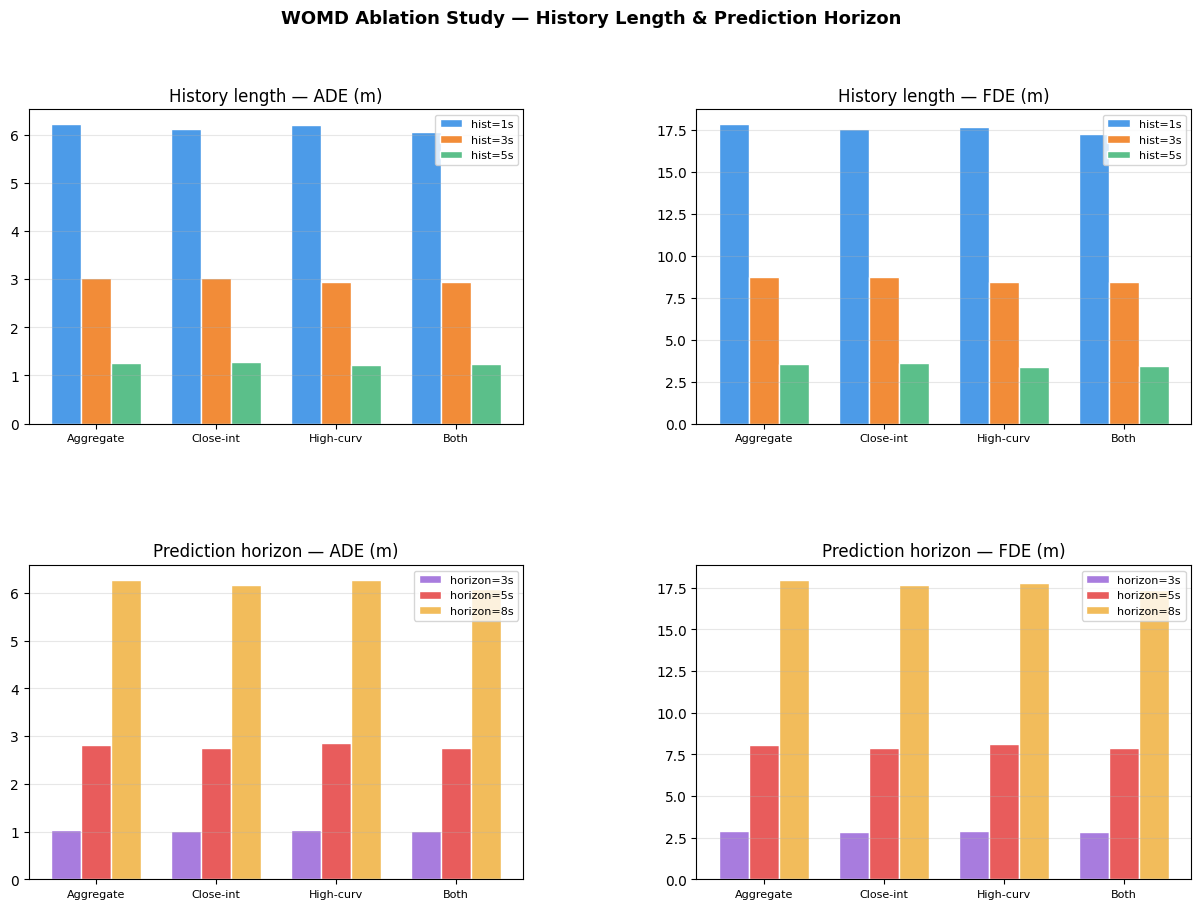

In [12]:
# Horizon ablation: use 1s history data, slice future to 3s/5s/8s
print("Loading 1s history data for horizon ablation...")
data_1s = load_prefix('features/val_v2/')

horizon_results = {}
for horizon_label, fut_steps in [('3s', 30), ('5s', 50), ('8s', 80)]:
    print(f"\nHorizon = {horizon_label} ({fut_steps} steps)")

    # Slice future arrays to fut_steps
    data_h = {k: v.copy() for k, v in data_1s.items()}
    data_h['future_xy']    = data_1s['future_xy'][:, :fut_steps, :]
    data_h['future_valid'] = data_1s['future_valid'][:, :fut_steps]

    class HorizonDataset(Dataset):
        def __init__(self, d):
            self.hxy  = torch.tensor(d['history_xy'],   dtype=torch.float32)
            self.hhv  = torch.tensor(d['history_hv'],   dtype=torch.float32)
            self.fxy  = torch.tensor(d['future_xy'],    dtype=torch.float32)
            self.fval = torch.tensor(d['future_valid'], dtype=torch.float32)
        def __len__(self): return len(self.hxy)
        def __getitem__(self, i):
            return self.hxy[i], self.hhv[i], self.fxy[i], self.fval[i]

    model = GRUModel(hist_steps=11, hidden=256, out_steps=fut_steps).to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=60)
    loader = DataLoader(HorizonDataset(data_h), batch_size=512,
                        shuffle=True, num_workers=2, pin_memory=True)

    for epoch in range(60):
        model.train()
        total = 0
        for hxy, hhv, fxy, fval in loader:
            hxy, hhv = hxy.to(device), hhv.to(device)
            fxy, fval = fxy.to(device), fval.to(device)
            pred = model(hxy, hhv)
            loss = (torch.norm(pred - fxy, dim=-1) * fval).sum() / (fval.sum() + 1e-6)
            optim.zero_grad(); loss.backward(); optim.step()
            total += loss.item()
        sched.step()
        if (epoch+1) % 20 == 0:
            print(f"  epoch {epoch+1}/60  loss={total/len(loader):.4f}")

    result = evaluate_model(model, data_h)
    horizon_results[horizon_label] = result
    for slice_name, (ade, fde) in result.items():
        print(f"  {slice_name:<16} ADE={ade:.3f}  FDE={fde:.3f}")

print("\n✅ Horizon ablation complete")

# ── Final summary plot ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 10))
fig.suptitle('WOMD Ablation Study — History Length & Prediction Horizon',
             fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

slice_names  = ['Aggregate', 'Close-int', 'High-curv', 'Both']
hist_labels  = ['1s', '3s', '5s']
horiz_labels = ['3s', '5s', '8s']
colors_hist  = ['#4C9BE8', '#F28C38', '#5BBF8A']
colors_horiz = ['#A87CDE', '#E85C5C', '#F2BC5B']

# History ADE
ax1 = fig.add_subplot(gs[0, 0])
x   = np.arange(len(slice_names))
w   = 0.25
for i, (label, color) in enumerate(zip(hist_labels, colors_hist)):
    vals = [ablation_results[label][s][0] for s in slice_names]
    ax1.bar(x + i*w, vals, w, label=f'hist={label}', color=color, edgecolor='white')
ax1.set_title('History length — ADE (m)')
ax1.set_xticks(x + w); ax1.set_xticklabels(slice_names, fontsize=8)
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

# History FDE
ax2 = fig.add_subplot(gs[0, 1])
for i, (label, color) in enumerate(zip(hist_labels, colors_hist)):
    vals = [ablation_results[label][s][1] for s in slice_names]
    ax2.bar(x + i*w, vals, w, label=f'hist={label}', color=color, edgecolor='white')
ax2.set_title('History length — FDE (m)')
ax2.set_xticks(x + w); ax2.set_xticklabels(slice_names, fontsize=8)
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

# Horizon ADE
ax3 = fig.add_subplot(gs[1, 0])
for i, (label, color) in enumerate(zip(horiz_labels, colors_horiz)):
    vals = [horizon_results[label][s][0] for s in slice_names]
    ax3.bar(x + i*w, vals, w, label=f'horizon={label}', color=color, edgecolor='white')
ax3.set_title('Prediction horizon — ADE (m)')
ax3.set_xticks(x + w); ax3.set_xticklabels(slice_names, fontsize=8)
ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

# Horizon FDE
ax4 = fig.add_subplot(gs[1, 1])
for i, (label, color) in enumerate(zip(horiz_labels, colors_horiz)):
    vals = [horizon_results[label][s][1] for s in slice_names]
    ax4.bar(x + i*w, vals, w, label=f'horizon={label}', color=color, edgecolor='white')
ax4.set_title('Prediction horizon — FDE (m)')
ax4.set_xticks(x + w); ax4.set_xticklabels(slice_names, fontsize=8)
ax4.legend(fontsize=8); ax4.grid(axis='y', alpha=0.3)

plt.savefig('/tmp/ablation_results.png', dpi=150, bbox_inches='tight')
bucket.blob('plots/ablation_results.png').upload_from_filename('/tmp/ablation_results.png')
print("✅ Ablation plot saved to GCS")

# Save results
import json
all_ablations = {'history': ablation_results, 'horizon': horizon_results}
def to_serializable(obj):
    if isinstance(obj, (np.float32, np.float64)): return float(obj)
    if isinstance(obj, (np.int32, np.int64)):     return int(obj)
    if isinstance(obj, dict):  return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [to_serializable(v) for v in obj]
    return obj
bucket.blob('results/ablation_results.json').upload_from_string(
    json.dumps(to_serializable(all_ablations), indent=2))
print("✅ Ablation results saved to GCS")
plt.show()